# Projet TP - Reconnaissance de panneaux (version fonctionnelle)

Ce notebook est conçu pour **s'exécuter de bout en bout**.

Il suit les 4 parties demandées :
1. Présentation du jeu de données
2. Méthodes classiques de reconnaissance
3. Méthode supervisée conçue et entraînée
4. Modèle pré-entraîné (transfer learning)

En cas d'absence de dataset GTSRB structuré, le notebook bascule en mode fallback avec les images locales et des pseudo-labels (démo fonctionnelle).

In [1]:
# Installation optionnelle
INSTALL_DEPS = True
if INSTALL_DEPS:
    import sys, subprocess
    pkgs = [
        'numpy', 'pandas', 'matplotlib', 'seaborn', 'opencv-python',
        'scikit-learn', 'scikit-image', 'tensorflow',
        'torch', 'torchvision'
    ]
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-U'] + pkgs)
    print('Dependances installees.')
else:
    print('Installation ignoree (INSTALL_DEPS=False).')

Dependances installees.


In [2]:
import os
import random
import time
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.svm import LinearSVC

from skimage.feature import hog

import tensorflow as tf
from tensorflow import keras

sns.set_theme(style='whitegrid')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

SEED = 42
set_seed(SEED)
print('TensorFlow:', tf.__version__)
print('Seed fixee:', SEED)

TensorFlow: 2.21.0
Seed fixee: 42


In [3]:
# Configuration chemins
PROJECT_ROOT = Path('..').resolve()
LOCAL_FLAT_DIR = PROJECT_ROOT / 'im' / 'panneaux'
LOCAL_GTSRB_DIR = PROJECT_ROOT / 'im' / 'gtsrb'

IMG_SIZE = (64, 64)
BATCH_SIZE = 32
EPOCHS_CNN = 8
EPOCHS_TL_FREEZE = 4
EPOCHS_TL_FINETUNE = 3
FAST_MODE = True
if FAST_MODE:
    EPOCHS_CNN = 4
    EPOCHS_TL_FREEZE = 2
    EPOCHS_TL_FINETUNE = 2

print('PROJECT_ROOT =', PROJECT_ROOT)
print('LOCAL_FLAT_DIR existe =', LOCAL_FLAT_DIR.exists())
print('LOCAL_GTSRB_DIR existe =', LOCAL_GTSRB_DIR.exists())

PROJECT_ROOT = C:\Users\madaggag\Documents\Python\Project\Cours\Traitement_Image
LOCAL_FLAT_DIR existe = True
LOCAL_GTSRB_DIR existe = True


GTSRB recupere via torchvision dans: C:\Users\madaggag\Documents\Python\Project\Cours\Traitement_Image\im\gtsrb


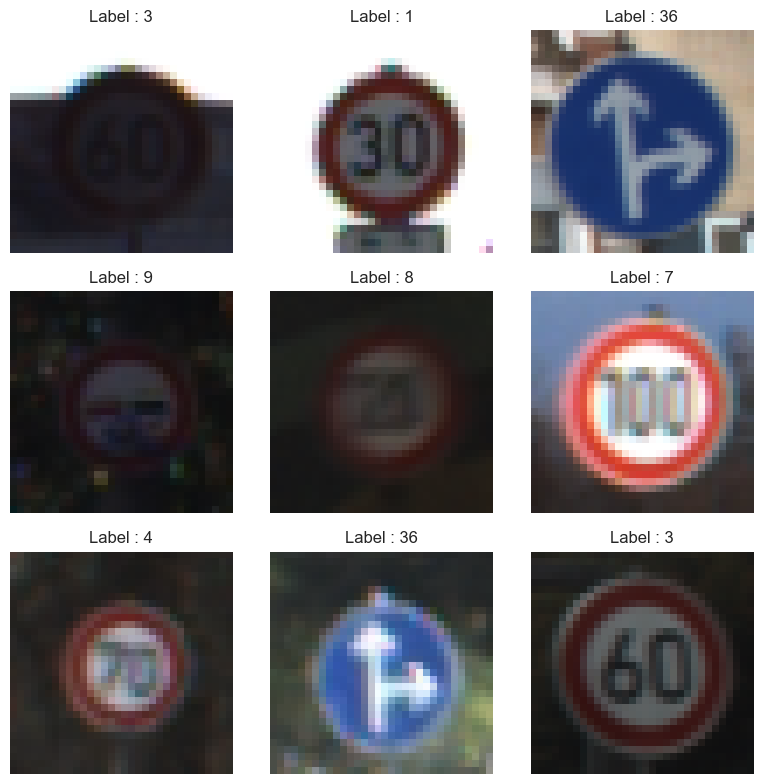

In [5]:
from torchvision.datasets import GTSRB
from torchvision import transforms
import numpy as np

# Telechargement unique GTSRB (reutilise ensuite)
DOWNLOAD_GTSRB_PYTORCH = True  # Passe a True pour telecharger via torchvision

if DOWNLOAD_GTSRB_PYTORCH:
    try:
        LOCAL_GTSRB_DIR.mkdir(parents=True, exist_ok=True)
        _ = GTSRB(root=str(LOCAL_GTSRB_DIR), split='train', download=True)
        _ = GTSRB(root=str(LOCAL_GTSRB_DIR), split='test', download=True)
        print('GTSRB recupere via torchvision dans:', LOCAL_GTSRB_DIR)
    except Exception as e:
        print('Echec telechargement PyTorch:', e)
        print("Installe torch/torchvision ou utilise l'option de telechargement alternative.")
else:
    print('Telechargement PyTorch desactive (DOWNLOAD_GTSRB_PYTORCH=False).')

# Chargement depuis LOCAL_GTSRB_DIR (deja telecharge)
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

train_dataset = GTSRB(
    root=str(LOCAL_GTSRB_DIR),
    split="train",
    download=False,
    transform=transform,
)

test_dataset = GTSRB(
    root=str(LOCAL_GTSRB_DIR),
    split="test",
    download=False,
    transform=transform,
)

# Visualisation rapide
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for ax in axes.flat:
    idx = random.randint(0, len(train_dataset) - 1)
    image, label = train_dataset[idx]

    # imshow attend un format HWC
    if hasattr(image, "permute"):
        img_np = image.permute(1, 2, 0).numpy()
    else:
        img_np = np.array(image)

    ax.imshow(img_np)
    ax.set_title(f"Label : {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Partie 1 - Presentation du jeu de donnees

Objectif : charger les donnees, compter images/classes, visualiser distribution et exemples.

Note : GTSRB est charge via torchvision et stocke dans `LOCAL_GTSRB_DIR`.

In [8]:
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMAGE_EXTS = {'.png', '.jpg', '.jpeg', '.ppm', '.bmp'}

def list_images(root: Path):
    if not root.exists():
        return []
    paths = []
    for ext in IMAGE_EXTS:
        paths.extend(root.rglob(f"*{ext}"))
    return paths


def _find_train_dir_candidates(root: Path):
    candidates = [
        root / 'Train',
        root / 'GTSRB' / 'Train',
        root / 'GTSRB' / 'Training',
        root / 'Final_Training' / 'Images',
        root / 'GTSRB' / 'Final_Training' / 'Images',
        root / 'gtsrb' / 'Final_Training' / 'Images',
        root / 'gtsrb' / 'Train',
        root / 'gtsrb' / 'Training',
        root / 'gtsrb' / 'GTSRB' / 'Training',
        root / 'gtsrb' / 'GTSRB' / 'Final_Training' / 'Images',
    ]
    return [c for c in candidates if c.exists() and c.is_dir()]

def load_gtsrb_like(root: Path):
    train_dirs = _find_train_dir_candidates(root)
    if len(train_dirs) == 0:
        return None

    rows = []
    used_train_dir = train_dirs[0]

    # Support structure classe->images
    class_dirs = [d for d in used_train_dir.iterdir() if d.is_dir()]
    if len(class_dirs) > 0:
        for class_dir in sorted(class_dirs, key=lambda x: x.name):
            for p in list_images(class_dir):
                rows.append({
                    'path': str(p),
                    'label_raw': class_dir.name,
                    'source': 'gtsrb',
                    'confidence': 1.0
                })

    # Fallback CSV style (certaines versions telechargees)
    if len(rows) == 0:
        csv_candidates = [
            root / 'Train.csv',
            root / 'gtsrb' / 'Train.csv',
            root / 'GTSRB' / 'Train.csv',
            root / 'gtsrb' / 'GTSRB' / 'Train.csv',
        ]
        csv_path = next((p for p in csv_candidates if p.exists()), None)
        if csv_path is not None:
            meta = pd.read_csv(csv_path)
            path_col = 'Path' if 'Path' in meta.columns else ('Filename' if 'Filename' in meta.columns else None)
            label_col = 'ClassId' if 'ClassId' in meta.columns else None
            if path_col is not None and label_col is not None:
                for _, r in meta.iterrows():
                    rel = str(r[path_col]).replace('\\', '/')
                    p = root / rel
                    if not p.exists():
                        p = (root / 'gtsrb' / rel) if (root / 'gtsrb').exists() else p
                    if not p.exists():
                        p = (root / 'GTSRB' / rel) if (root / 'GTSRB').exists() else p
                    if not p.exists():
                        p = (root / 'gtsrb' / 'GTSRB' / rel) if (root / 'gtsrb' / 'GTSRB').exists() else p
                    if p.exists() and p.suffix.lower() in IMAGE_EXTS:
                        rows.append({
                            'path': str(p),
                            'label_raw': str(r[label_col]),
                            'source': 'gtsrb',
                            'confidence': 1.0
                        })

    if not rows:
        return None
    return pd.DataFrame(rows)


def contour_signature(contour):
    moments = cv2.moments(contour)
    if abs(moments.get("m00", 0.0)) < 1e-6:
        return None

    cx = int(moments["m10"] / moments["m00"])
    cy = int(moments["m01"] / moments["m00"])
    pts = contour[:, 0, :]

    distances = []
    for p in pts:
        x, y = p
        d = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)
        distances.append(d)

    distances = np.array(distances)
    max_d = distances.max() if len(distances) else 0.0
    if max_d <= 1e-6:
        return None

    distances = distances / max_d
    return distances, (cx, cy)


def classify_signature(signature):

    std = np.std(signature)

    peaks = 0

    for i in range(1, len(signature)-1):

        if (
            signature[i] > signature[i-1]
            and signature[i] > signature[i+1]
            and signature[i] > 0.95
        ):
            peaks += 1

    # Cercle = rayon stable
    if std < 0.05:
        return "cercle"

    # Triangle = 3 gros pics
    if 2 <= peaks <= 4:
        return "triangle"

    # Octogone = plus de pics reguliers
    if 6 <= peaks <= 10:
        return "octogone"

    return "autre"


def analyze_panel(pil_image):

    image_np = np.array(pil_image)
    if image_np.ndim == 3 and image_np.shape[0] in (1, 3) and image_np.shape[0] < image_np.shape[1]:
        image_np = np.transpose(image_np, (1, 2, 0))
    if image_np.max() <= 1.0:
        image_np = (image_np * 255.0).astype(np.uint8)

    image_bgr = cv2.cvtColor(
        image_np,
        cv2.COLOR_RGB2BGR
    )

    img = cv2.resize(image_bgr, (128, 128))

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    red1 = cv2.inRange(hsv, (0, 60, 40), (12, 255, 255))
    red2 = cv2.inRange(hsv, (165, 60, 40), (180, 255, 255))
    red = cv2.bitwise_or(red1, red2)
    yellow = cv2.inRange(hsv, (15, 50, 50), (40, 255, 255))
    blue = cv2.inRange(hsv, (90, 50, 40), (135, 255, 255))

    mask = cv2.bitwise_or(cv2.bitwise_or(red, yellow), blue)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    contour_img = img.copy()
    signature = None
    pred = "autre"

    if contours:
        c = max(contours, key=cv2.contourArea)

        cv2.drawContours(
            contour_img,
            [c],
            -1,
            (0, 255, 0),
            2
        )

        result = contour_signature(c)
        if result is not None:
            signature, center = result
            cx, cy = center
            cv2.circle(
                contour_img,
                (cx, cy),
                4,
                (255, 0, 0),
                -1
            )
            pred = classify_signature(signature)

    return (
        cv2.cvtColor(img, cv2.COLOR_BGR2RGB),
        mask,
        cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB),
        signature,
        pred
    )


def shape_pseudo_label(img_bgr):
    h, w = img_bgr.shape[:2]
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    red1 = cv2.inRange(hsv, (0, 60, 40), (12, 255, 255))
    red2 = cv2.inRange(hsv, (165, 60, 40), (180, 255, 255))
    red = cv2.bitwise_or(red1, red2)
    yellow = cv2.inRange(hsv, (15, 50, 50), (40, 255, 255))
    blue = cv2.inRange(hsv, (90, 50, 40), (135, 255, 255))

    mask = cv2.bitwise_or(cv2.bitwise_or(red, yellow), blue)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return 'autre', 0.2

    c = max(contours, key=cv2.contourArea)
    peri = cv2.arcLength(c, True)
    if peri <= 1e-6:
        return 'autre', 0.2

    area = cv2.contourArea(c)
    area_ratio = float(area / (h * w))
    if area_ratio < 0.008:
        return 'autre', 0.3

    approx = cv2.approxPolyDP(c, 0.02 * peri, True)
    v = len(approx)
    circularity = float(4.0 * np.pi * area / (peri * peri))

    if v == 3:
        return 'triangle', 0.85
    if 6 <= v <= 10 and circularity > 0.72:
        return 'octogone', 0.88
    if circularity >= 0.78 or v >= 11:
        return 'cercle', 0.82

    return 'autre', 0.4


def load_flat_with_pseudo_labels(folder: Path):
    rows = []
    paths = sorted(list_images(folder))

    unique_by_stem = {}
    for p in paths:
        key = p.stem.lower()
        priority = {'.png': 0, '.jpg': 1, '.jpeg': 1, '.ppm': 2, '.bmp': 3}.get(p.suffix.lower(), 9)
        if key not in unique_by_stem or priority < unique_by_stem[key][0]:
            unique_by_stem[key] = (priority, p)

    for _, (_, p) in sorted(unique_by_stem.items(), key=lambda kv: kv[0]):
        img = cv2.imread(str(p), cv2.IMREAD_COLOR)
        if img is None:
            continue
        lbl, conf = shape_pseudo_label(img)
        rows.append({'path': str(p), 'label_raw': lbl, 'source': 'pseudo_local', 'confidence': float(conf)})

    if not rows:
        return None
    return pd.DataFrame(rows)

df = load_gtsrb_like(LOCAL_GTSRB_DIR)
if df is None:
    df = load_flat_with_pseudo_labels(LOCAL_FLAT_DIR)

if df is None or len(df) < 8:
    raise RuntimeError(
        'Aucune base exploitable. Placez un dataset GTSRB dans im/gtsrb (PyTorch/manuel) '
        'ou au minimum des images dans im/panneaux.'
    )

print('Source:', df['source'].iloc[0])
print('Nombre images:', len(df))
print('Nombre classes detectees:', df['label_raw'].nunique())
if 'confidence' in df.columns:
    print('Confiance moyenne pseudo-labels:', round(float(df['confidence'].mean()), 3))

Source: gtsrb
Nombre images: 26640
Nombre classes detectees: 43
Confiance moyenne pseudo-labels: 1.0


C:\Users\madaggag\AppData\Local\Temp\ipykernel_452\542794196.py:144: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  image_np = np.array(pil_image)


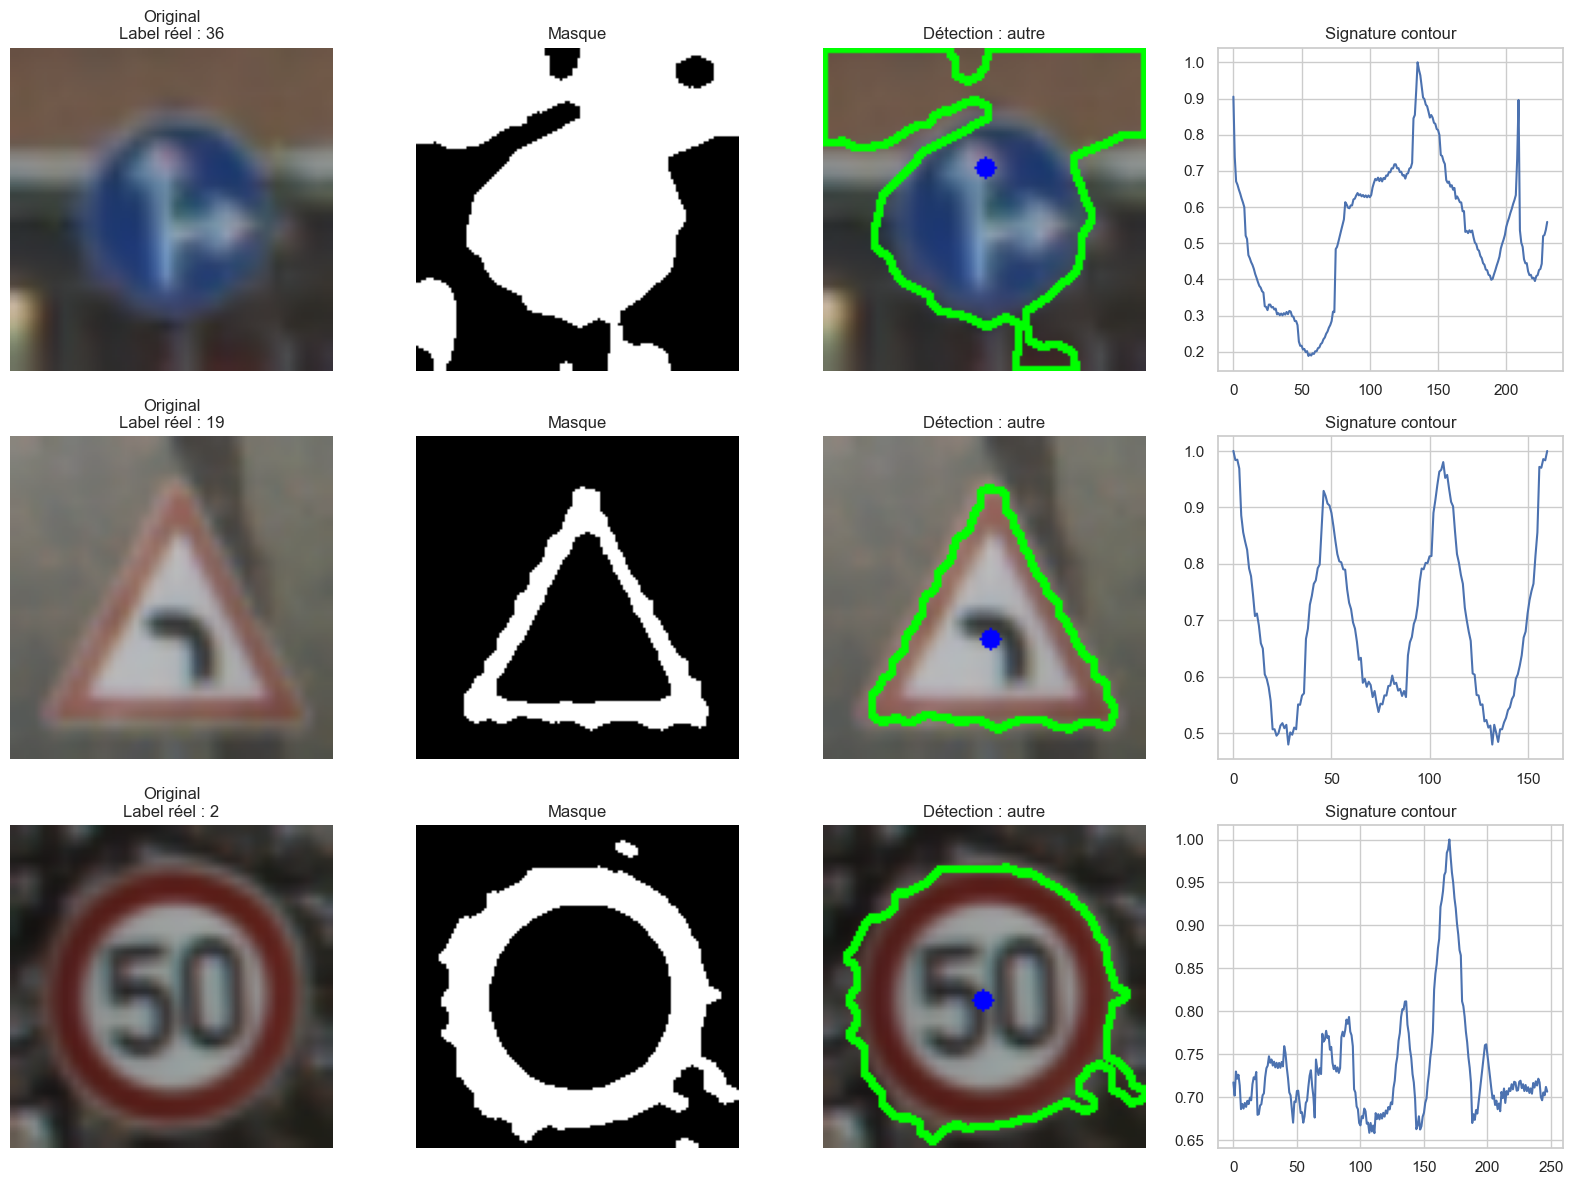

In [9]:
def read_rgb(path, size=None):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    if size is not None:
        img = cv2.resize(img, size, interpolation=cv2.INTER_AREA)
    return img

    contour_img = img.copy()

    signature = None
    pred = "autre"

    if contours:

        c = max(contours, key=cv2.contourArea)

        cv2.drawContours(
            contour_img,
            [c],
            -1,
            (0,255,0),
            2
        )

        result = contour_signature(c)

        if result is not None:

            signature, center = result

            cx, cy = center

            cv2.circle(
                contour_img,
                (cx, cy),
                4,
                (255,0,0),
                -1
            )

            pred = classify_signature(signature)

    return (
        cv2.cvtColor(img, cv2.COLOR_BGR2RGB),
        mask,
        cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB),
        signature,
        pred
    )


# =========================
# Affichage
# =========================

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for row in range(3):

    idx = random.randint(0, len(train_dataset)-1)

    image, true_label = train_dataset[idx]

    original, mask, contour, signature, pred = analyze_panel(image)

    axes[row, 0].imshow(original)
    axes[row, 0].set_title(f"Original\nLabel réel : {true_label}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(mask, cmap="gray")
    axes[row, 1].set_title("Masque")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(contour)
    axes[row, 2].set_title(f"Détection : {pred}")
    axes[row, 2].axis("off")

    if signature is not None:
        axes[row, 3].plot(signature)
        axes[row, 3].set_title("Signature contour")

plt.tight_layout()
plt.show()

Train shape: (26640, 32, 32, 3)
Test shape: (12630, 32, 32, 3)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 629,739 (2.40 MB)

 Trainable params: 629,291 (2.40 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.3033 - loss: 2.4410 - val_accuracy: 0.4572 - val_loss: 1.8301 - learning_rate: 0.0010
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.5475 - loss: 1.3591 - val_accuracy: 0.7271 - val_loss: 0.7887 - learning_rate: 0.0010
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.6725 - loss: 0.9587 - val_accuracy: 0.8352 - val_loss: 0.5081 - learning_rate: 0.0010
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.7485 - loss: 0.7321 - val_accuracy: 0.8971 - val_loss: 0.3173 - learning_rate: 0.0010
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.7958 - loss: 0.5917 - val_accuracy: 0.8979 - val_loss: 0.2853 - learning_rate: 0.0010
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.8332 - loss: 0.4921 - val_accuracy: 0.9452 - val_loss: 0.1789 - learning_rate: 0.0010
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.8490 - l

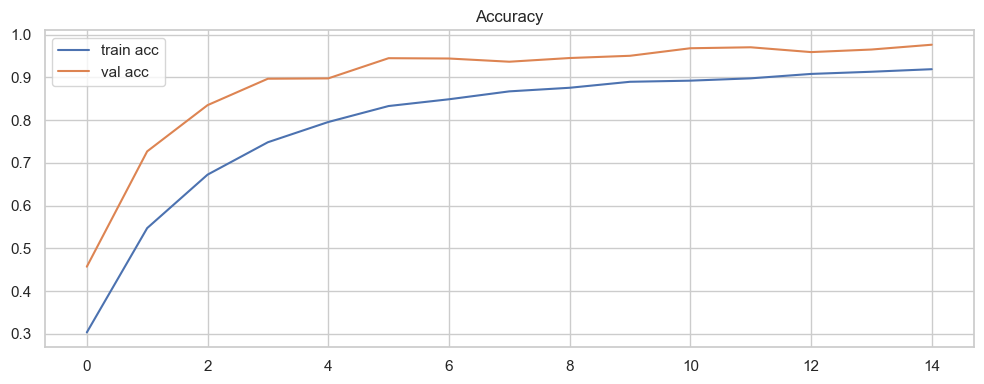

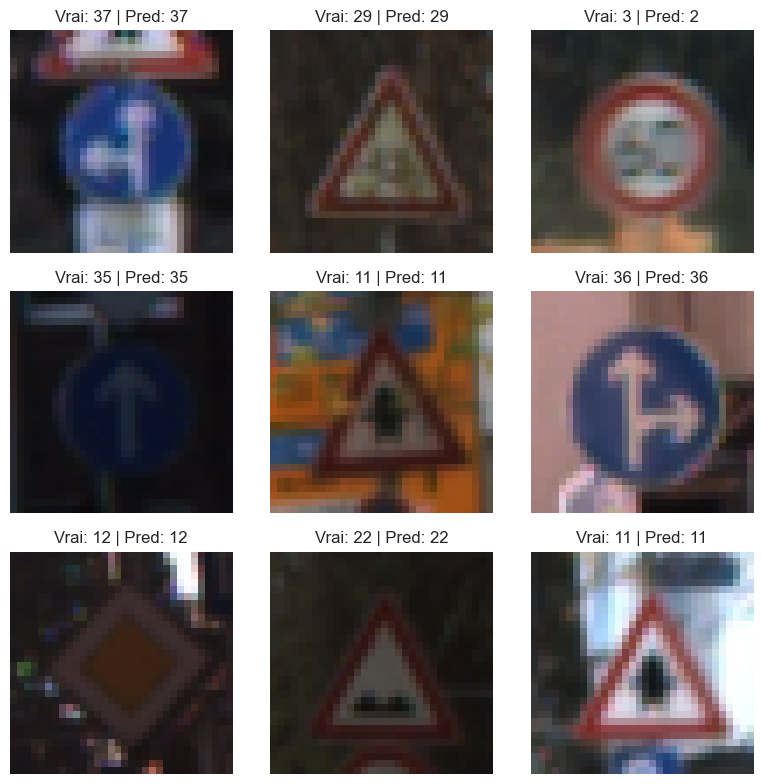

In [10]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import random
from torchvision.datasets import GTSRB
from torchvision import transforms

# Pipeline CNN GTSRB (conversion + entrainement)
# =========================
# 2. CONVERSION PYTORCH -> NUMPY
# =========================

def dataset_to_numpy(dataset, max_samples=None):

    X, y = [], []

    dataset_size = len(dataset)
    if max_samples is None or max_samples >= dataset_size or max_samples == 1:
        max_len = dataset_size
    elif 0 < max_samples < 1:
        max_len = max(1, int(dataset_size * max_samples))
    else:
        max_len = min(dataset_size, int(max_samples))

    # indices SAFE bases sur dataset reel
    indices = random.sample(range(dataset_size), max_len)

    for i in indices:

        img, label = dataset[i]

        if hasattr(img, "numpy"):
            img = img.numpy()

        img = np.array(img)

        # gestion format (C, H, W)
        if img.ndim == 3 and img.shape[0] in (1, 3) and img.shape[0] < img.shape[1]:
            img = np.transpose(img, (1, 2, 0))

        # securite : conversion RGB si besoin
        if len(img.shape) == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

        # resize obligatoire CNN
        img = cv2.resize(img, (32, 32))

        # normalisation
        img = img.astype(np.float32)
        if img.max() > 1.0:
            img = img / 255.0

        # securite shape
        if img.shape != (32, 32, 3):
            continue

        X.append(img)
        y.append(label)

    if not X:
        raise ValueError("Aucun echantillon valide apres conversion.")

    return np.stack(X), np.array(y)

X_train, y_train = dataset_to_numpy(train_dataset)
X_test, y_test = dataset_to_numpy(test_dataset)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Dossier pour les figures du compte rendu
fig_dir = PROJECT_ROOT / "Rapports" / "Capture_ecran_Projet"
fig_dir.mkdir(parents=True, exist_ok=True)

# =========================
# 3. CNN MODEL
# =========================

def CNN_model():

    data_aug = tf.keras.Sequential([
        tf.keras.layers.RandomFlip('horizontal'),
        tf.keras.layers.RandomRotation(0.1),
        tf.keras.layers.RandomZoom(0.1),
    ])

    model = tf.keras.Sequential([

        tf.keras.Input(shape=(32, 32, 3)),
        data_aug,

        tf.keras.layers.Conv2D(32, (3,3), padding="same"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.MaxPooling2D((2,2)),

        tf.keras.layers.Conv2D(64, (3,3), padding="same"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.MaxPooling2D((2,2)),

        tf.keras.layers.Conv2D(128, (3,3), padding="same"),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),
        tf.keras.layers.MaxPooling2D((2,2)),

        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dropout(0.4),

        tf.keras.layers.Dense(43, activation="softmax")
    ])

    return model


model = CNN_model()

# =========================
# 4. COMPILATION
# =========================

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# =========================
# 5. TRAINING
# =========================

epochs_gtsrb = 15
batch_gtsrb = 64

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, min_lr=1e-5),
]

history = model.fit(
    X_train,
    y_train,
    epochs=epochs_gtsrb,
    batch_size=batch_gtsrb,
    validation_split=0.1,
    callbacks=callbacks
)

# =========================
# 6. EVALUATION
# =========================

test_loss, test_acc = model.evaluate(X_test, y_test)

print("\nTest accuracy:", test_acc)

# =========================
# 7. VISUALISATION
# =========================

plt.figure(figsize=(10,4))
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.legend()
plt.title("Accuracy")
plt.tight_layout()
plt.savefig(fig_dir / "accuracy_cnn_gtsrb.png")
plt.show()

# =========================
# 8. EXEMPLES DE PREDICTIONS
# =========================

fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for ax in axes.flat:

    idx = random.randint(0, len(X_test) - 1)

    img = X_test[idx]
    true = y_test[idx]

    pred = np.argmax(model.predict(img[np.newaxis, ...], verbose=0))

    ax.imshow(img)
    ax.set_title(f"Vrai: {true} | Pred: {pred}")
    ax.axis("off")

plt.tight_layout()
plt.savefig(fig_dir / "predictions_cnn_gtsrb.png")
plt.show()

In [11]:
# Resume rapide
try:
    last_val = float(history.history.get('val_accuracy', [None])[-1])
except Exception:
    last_val = None

print("Test accuracy (GTSRB CNN):", float(test_acc))
print("Derniere val accuracy:", last_val)

Test accuracy (GTSRB CNN): 0.9145684838294983
Derniere val accuracy: 0.9767267107963562


In [12]:
# Fine-tuning court pour viser 90%
# LR plus faible pour affiner le modele
ft_epochs = 8
ft_batch = batch_gtsrb if 'batch_gtsrb' in globals() else 64

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

ft_callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=2, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=1, factor=0.5, min_lr=1e-6),
]

history_ft = model.fit(
    X_train,
    y_train,
    epochs=ft_epochs,
    batch_size=ft_batch,
    validation_split=0.1,
    callbacks=ft_callbacks
)

ft_loss, ft_acc = model.evaluate(X_test, y_test)
print("\nTest accuracy apres fine-tuning:", float(ft_acc))

Epoch 1/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9404 - loss: 0.1752 - val_accuracy: 0.9857 - val_loss: 0.0472 - learning_rate: 1.0000e-04
Epoch 2/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.9487 - loss: 0.1518 - val_accuracy: 0.9869 - val_loss: 0.0445 - learning_rate: 1.0000e-04
Epoch 3/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.9525 - loss: 0.1429 - val_accuracy: 0.9880 - val_loss: 0.0438 - learning_rate: 1.0000e-04
Epoch 4/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.9535 - loss: 0.1411 - val_accuracy: 0.9887 - val_loss: 0.0401 - learning_rate: 1.0000e-04
Epoch 5/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.9550 - loss: 0.1377 - val_accuracy: 0.9887 - val_loss: 0.0395 - learning_rate: 1.0000e-04
Epoch 6/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.9555 - loss: 0.1327 - val_accuracy: 0.9884 - val_loss: 0.0387 - learning_rate: 1.0000e-04
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.921

In [13]:
# Sauvegarde du modele fine-tune (TensorFlow)
SAVE_MODEL = True
if SAVE_MODEL:
    model_path = PROJECT_ROOT / "Projet" / "model_cnn_gtsrb.keras"
    model_path.parent.mkdir(parents=True, exist_ok=True)
    model.save(model_path)
    print("Modele sauvegarde:", model_path)
else:
    print("Sauvegarde ignoree (SAVE_MODEL=False).")

Modele sauvegarde: C:\Users\madaggag\Documents\Python\Project\Cours\Traitement_Image\Projet\model_cnn_gtsrb.keras


In [14]:
# Encodage des classes + split train/val/test
encoder = LabelEncoder()
df['label_idx'] = encoder.fit_transform(df['label_raw'])
class_names = list(encoder.classes_)
num_classes = len(class_names)

stratify_col = df['label_idx'] if df['label_idx'].value_counts().min() >= 2 else None
train_df, test_df = train_test_split(df, test_size=0.25, random_state=SEED, stratify=stratify_col)
stratify_train = train_df['label_idx'] if train_df['label_idx'].value_counts().min() >= 2 else None
train_df, val_df = train_test_split(train_df, test_size=0.25, random_state=SEED, stratify=stratify_train)

print(f'Train={len(train_df)} | Val={len(val_df)} | Test={len(test_df)} | Classes={num_classes}')
print('Classes:', class_names)

Train=14985 | Val=4995 | Test=6660 | Classes=43
Classes: ['00000', '00001', '00002', '00003', '00004', '00005', '00006', '00007', '00008', '00009', '00010', '00011', '00012', '00013', '00014', '00015', '00016', '00017', '00018', '00019', '00020', '00021', '00022', '00023', '00024', '00025', '00026', '00027', '00028', '00029', '00030', '00031', '00032', '00033', '00034', '00035', '00036', '00037', '00038', '00039', '00040', '00041', '00042']


## Partie 2 - Approche classique (descripteurs + SVM)

Objectif : extraire des descripteurs HOG + couleur, puis entraîner un SVM.

In [15]:
def extract_features_classic(path, size=(64, 64)):
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    bgr = cv2.resize(bgr, size, interpolation=cv2.INTER_AREA)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

    hog_vec = hog(gray, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), block_norm='L2-Hys')

    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    hist_h = cv2.calcHist([hsv], [0], None, [16], [0, 180]).flatten()
    hist_s = cv2.calcHist([hsv], [1], None, [16], [0, 256]).flatten()
    hist_v = cv2.calcHist([hsv], [2], None, [16], [0, 256]).flatten()
    color_vec = np.concatenate([hist_h, hist_s, hist_v])
    color_vec = color_vec / (np.linalg.norm(color_vec) + 1e-8)

    return np.concatenate([hog_vec, color_vec]).astype(np.float32)

def build_xy(dataframe):
    X, y = [], []
    for _, row in dataframe.iterrows():
        X.append(extract_features_classic(row['path'], size=IMG_SIZE))
        y.append(int(row['label_idx']))
    return np.array(X), np.array(y)

X_train, y_train = build_xy(train_df)
X_val, y_val = build_xy(val_df)
X_test, y_test = build_xy(test_df)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

t0 = time.time()
svm = LinearSVC(C=1.0, class_weight='balanced', max_iter=7000)
svm.fit(X_train_s, y_train)
time_classic = time.time() - t0

pred_classic = svm.predict(X_test_s)
acc_classic = accuracy_score(y_test, pred_classic)
pr_classic, rc_classic, f1_classic, _ = precision_recall_fscore_support(y_test, pred_classic, average='weighted', zero_division=0)

print('Approche classique - resultat test')
print(f'accuracy={acc_classic:.4f} | precision={pr_classic:.4f} | recall={rc_classic:.4f} | f1={f1_classic:.4f}')
print(f'temps entrainement={time_classic:.2f}s')
print(classification_report(y_test, pred_classic, target_names=[str(c) for c in class_names], zero_division=0))

Approche classique - resultat test
accuracy=0.9608 | precision=0.9609 | recall=0.9608 | f1=0.9608
temps entrainement=11852.17s
              precision    recall  f1-score   support

       00000       0.97      0.95      0.96        37
       00001       0.92      0.94      0.93       375
       00002       0.90      0.89      0.90       375
       00003       0.94      0.93      0.94       240
       00004       0.96      0.96      0.96       330
       00005       0.87      0.86      0.87       315
       00006       1.00      0.97      0.99        75
       00007       0.94      0.93      0.94       240
       00008       0.91      0.93      0.92       240
       00009       0.98      0.95      0.96       248
       00010       0.96      0.99      0.97       337
       00011       0.97      0.98      0.97       225
       00012       1.00      1.00      1.00       353
       00013       1.00      0.99      1.00       360
       00014       0.99      0.99      0.99       135
       0

C:\Users\madaggag\AppData\Local\Temp\ipykernel_452\3501389487.py:4: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  image_np = np.array(pil_image)


Vertices     : 10
Circularity  : 0.2318484592979524
Area         : 5869.5
Vertices     : 9
Circularity  : 0.603355543627584
Area         : 4579.5
Vertices     : 14
Circularity  : 0.37634898853341164
Area         : 10321.0


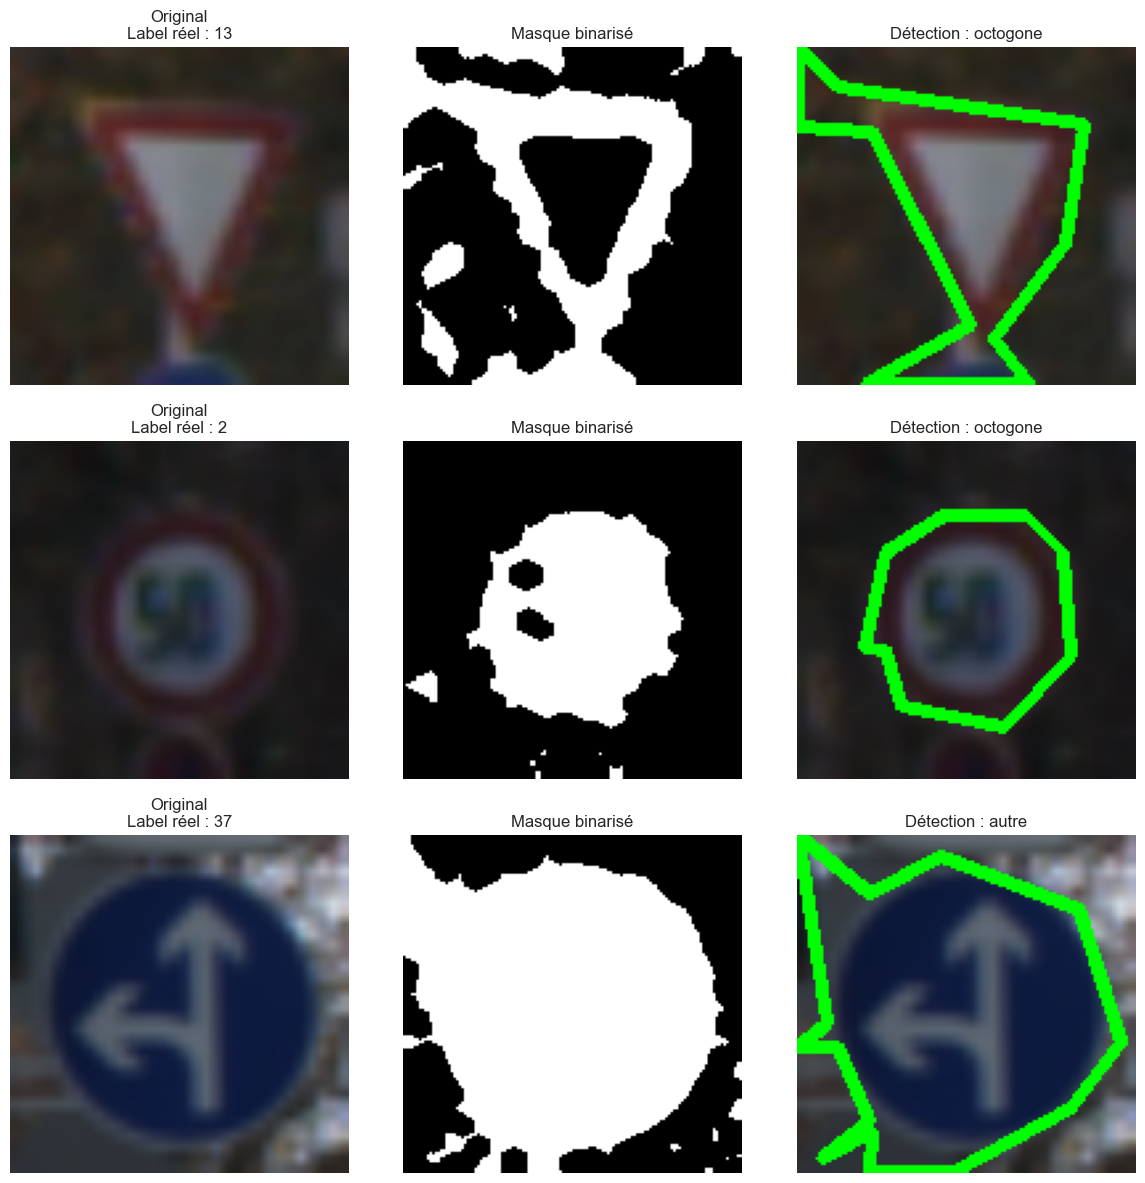

In [16]:
def debug_shape_detection(pil_image):

    # PIL/torch -> OpenCV
    image_np = np.array(pil_image)
    if image_np.ndim == 3 and image_np.shape[0] in (1, 3) and image_np.shape[0] < image_np.shape[1]:
        image_np = np.transpose(image_np, (1, 2, 0))
    if image_np.max() <= 1.0:
        image_np = (image_np * 255.0).astype(np.uint8)

    image_bgr = cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR)

    # Resize
    img = cv2.resize(image_bgr, (128, 128))

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Couleurs
    red1 = cv2.inRange(hsv, (0, 60, 40), (12, 255, 255))
    red2 = cv2.inRange(hsv, (165, 60, 40), (180, 255, 255))
    red = cv2.bitwise_or(red1, red2)

    yellow = cv2.inRange(hsv, (15, 50, 50), (40, 255, 255))

    blue = cv2.inRange(hsv, (90, 50, 40), (135, 255, 255))

    # Fusion
    mask = cv2.bitwise_or(cv2.bitwise_or(red, yellow), blue)

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (5, 5)
    )

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=2
    )

    # Contours
    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    contour_img = img.copy()

    detected_label = "autre"

    if contours:

        c = max(contours, key=cv2.contourArea)

        peri = cv2.arcLength(c, True)

        approx = cv2.approxPolyDP(
            c,
            0.018 * peri,
            True
        )

        v = len(approx)

        area = cv2.contourArea(c)

        circularity = (
            4 * np.pi * area / (peri * peri)
            if peri > 0 else 0
        )

        # Dessin contour
        cv2.drawContours(
            contour_img,
            [approx],
            -1,
            (0, 255, 0),
            3
        )

        # Heuristiques
        if v == 3:
            detected_label = "triangle"

        elif 6 <= v <= 10:
            detected_label = "octogone"

        elif circularity > 0.75:
            detected_label = "cercle"

        print("Vertices     :", v)
        print("Circularity  :", circularity)
        print("Area         :", area)

    return (
        cv2.cvtColor(img, cv2.COLOR_BGR2RGB),
        mask,
        cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB),
        detected_label
    )


# =========================
# Affichage debug
# =========================

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for row in range(3):

    idx = random.randint(0, len(train_dataset) - 1)

    image, true_label = train_dataset[idx]

    original, mask, contour, pred = debug_shape_detection(image)

    axes[row, 0].imshow(original)
    axes[row, 0].set_title(f"Original\nLabel réel : {true_label}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(mask, cmap='gray')
    axes[row, 1].set_title("Masque binarisé")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(contour)
    axes[row, 2].set_title(f"Détection : {pred}")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

## Partie 3 - Méthode supervisée (CNN maison)

Objectif : entraîner une architecture CNN simple, analyser les performances et faire des ablations.

In [ ]:
def load_tensor_xy(dataframe, size=(64, 64)):
    X, y = [], []
    for _, row in dataframe.iterrows():
        bgr = cv2.imread(str(row['path']), cv2.IMREAD_COLOR)
        bgr = cv2.resize(bgr, size, interpolation=cv2.INTER_AREA)
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        X.append(rgb.astype(np.float32) / 255.0)
        y.append(int(row['label_idx']))
    return np.array(X), np.array(y)

Xtr, ytr = load_tensor_xy(train_df, size=IMG_SIZE)
Xva, yva = load_tensor_xy(val_df, size=IMG_SIZE)
Xte, yte = load_tensor_xy(test_df, size=IMG_SIZE)

def make_cnn(use_aug=True, dropout=0.3, base=24):
    inp = keras.Input(shape=(IMG_SIZE[1], IMG_SIZE[0], 3))
    x = inp
    if use_aug:
        aug = keras.Sequential([
            keras.layers.RandomFlip('horizontal'),
            keras.layers.RandomRotation(0.08),
            keras.layers.RandomZoom(0.1),
        ])
        x = aug(x)

    x = keras.layers.Conv2D(base, 3, padding='same', activation='relu')(x)
    x = keras.layers.MaxPooling2D()(x)
    x = keras.layers.Conv2D(base * 2, 3, padding='same', activation='relu')(x)
    x = keras.layers.MaxPooling2D()(x)
    x = keras.layers.Conv2D(base * 4, 3, padding='same', activation='relu')(x)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(dropout)(x)
    out = keras.layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

cw = compute_class_weight(class_weight='balanced', classes=np.unique(ytr), y=ytr)
class_weight = {int(c): float(w) for c, w in zip(np.unique(ytr), cw)}

cnn = make_cnn(use_aug=True, dropout=0.3, base=24)
t0 = time.time()
hist_cnn = cnn.fit(
    Xtr, ytr,
    validation_data=(Xva, yva),
    epochs=EPOCHS_CNN,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)],
    verbose=1
)
time_cnn = time.time() - t0

pred_cnn = np.argmax(cnn.predict(Xte, verbose=0), axis=1)
acc_cnn = accuracy_score(yte, pred_cnn)
pr_cnn, rc_cnn, f1_cnn, _ = precision_recall_fscore_support(yte, pred_cnn, average='weighted', zero_division=0)

print('CNN maison - resultat test')
print(f'accuracy={acc_cnn:.4f} | precision={pr_cnn:.4f} | recall={rc_cnn:.4f} | f1={f1_cnn:.4f}')
print(f'temps entrainement={time_cnn:.2f}s')

Epoch 1/4
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.0514 - loss: 3.5144 - val_accuracy: 0.0653 - val_loss: 3.3016
Epoch 2/4
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.0817 - loss: 3.2131 - val_accuracy: 0.1139 - val_loss: 3.1628
Epoch 3/4
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.1091 - loss: 3.0235 - val_accuracy: 0.1441 - val_loss: 2.9974
Epoch 4/4
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.1299 - loss: 2.8695 - val_accuracy: 0.1429 - val_loss: 2.9540
CNN maison - resultat test
accuracy=0.1495 | precision=0.2004 | recall=0.1495 | f1=0.1253
temps entrainement=44.15s


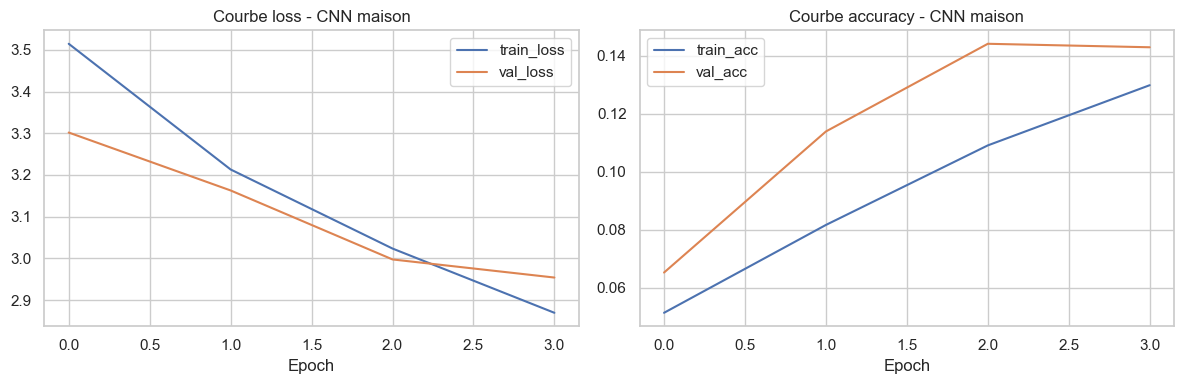

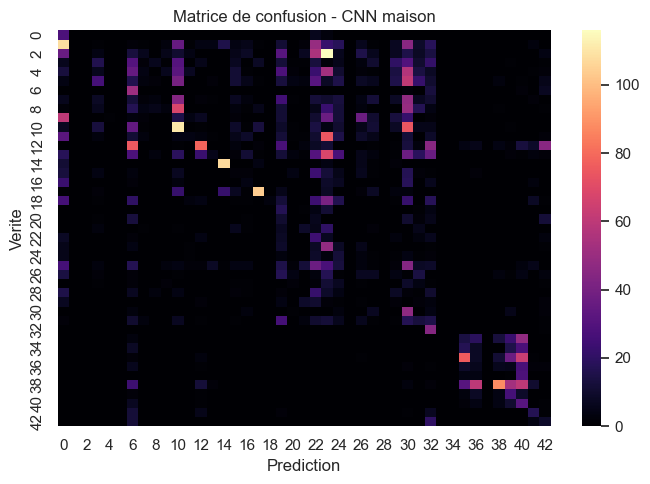

In [18]:
fig_dir = PROJECT_ROOT / "Rapports" / "Capture_ecran_Projet"
fig_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(hist_cnn.history['loss'], label='train_loss')
plt.plot(hist_cnn.history['val_loss'], label='val_loss')
plt.title('Courbe loss - CNN maison')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist_cnn.history['accuracy'], label='train_acc')
plt.plot(hist_cnn.history['val_accuracy'], label='val_acc')
plt.title('Courbe accuracy - CNN maison')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "courbes_cnn_maison.png")
plt.show()

cm_cnn = confusion_matrix(yte, pred_cnn)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_cnn, annot=False, cmap='magma')
plt.title('Matrice de confusion - CNN maison')
plt.xlabel('Prediction')
plt.ylabel('Verite')
plt.tight_layout()
plt.savefig(fig_dir / "confusion_cnn_maison.png")
plt.show()

In [19]:
# Ablations (3 experiences minimum)
def run_ablation(name, use_aug, use_class_weight, dropout, base):
    model = make_cnn(use_aug=use_aug, dropout=dropout, base=base)
    t0 = time.time()
    model.fit(
        Xtr, ytr,
        validation_data=(Xva, yva),
        epochs=max(2, EPOCHS_CNN - 1),
        batch_size=BATCH_SIZE,
        class_weight=(class_weight if use_class_weight else None),
        verbose=0
    )
    elapsed = time.time() - t0
    pred = np.argmax(model.predict(Xva, verbose=0), axis=1)
    acc = accuracy_score(yva, pred)
    pr, rc, f1, _ = precision_recall_fscore_support(yva, pred, average='weighted', zero_division=0)
    return {
        'experience': name,
        'augmentation': use_aug,
        'class_weight': use_class_weight,
        'dropout': dropout,
        'base_filters': base,
        'val_accuracy': acc,
        'val_precision': pr,
        'val_recall': rc,
        'val_f1': f1,
        'train_time_s': elapsed
    }

ablation_cfgs = [
    ('A0_baseline', True, True, 0.3, 24),
    ('A1_sans_augmentation', False, True, 0.3, 24),
    ('A2_sans_class_weight', True, False, 0.3, 24),
    ('A3_plus_petit', True, True, 0.2, 16),
]

ablation_results = [run_ablation(*cfg) for cfg in ablation_cfgs]
ablation_df = pd.DataFrame(ablation_results).sort_values('val_f1', ascending=False)
ablation_df

,experience,augmentation,class_weight,dropout,base_filters,val_accuracy,val_precision,val_recall,val_f1,train_time_s
2,A2_sans_class_weight,True,False,0.3,24,0.224424,0.166829,0.224424,0.162751,47.829954
3,A3_plus_petit,True,True,0.2,16,0.116116,0.142203,0.116116,0.098711,57.504392
0,A0_baseline,True,True,0.3,24,0.122322,0.193948,0.122322,0.097940,33.955896
1,A1_sans_augmentation,False,True,0.3,24,0.127127,0.201627,0.127127,0.095367,30.033772


## Partie 4 - Modèle pré-entraîné (Transfer Learning)

Objectif : comparer un backbone MobileNetV2 au CNN maison.

In [20]:
IMG_TL = (96, 96)
Xtr_tl, ytr_tl = load_tensor_xy(train_df, size=IMG_TL)
Xva_tl, yva_tl = load_tensor_xy(val_df, size=IMG_TL)
Xte_tl, yte_tl = load_tensor_xy(test_df, size=IMG_TL)

def build_tl_model(n_classes):
    inp = keras.Input(shape=(IMG_TL[1], IMG_TL[0], 3))
    x = keras.applications.mobilenet_v2.preprocess_input(inp * 255.0)
    try:
        base = keras.applications.MobileNetV2(include_top=False, weights='imagenet', input_shape=(IMG_TL[1], IMG_TL[0], 3))
        print('MobileNetV2 charge avec poids ImageNet.')
    except Exception as e:
        print('Chargement ImageNet impossible, fallback weights=None ->', e)
        base = keras.applications.MobileNetV2(include_top=False, weights=None, input_shape=(IMG_TL[1], IMG_TL[0], 3))

    base.trainable = False
    x = base(x, training=False)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(0.2)(x)
    out = keras.layers.Dense(n_classes, activation='softmax')(x)

    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model, base

tl_model, tl_base = build_tl_model(num_classes)
t0 = time.time()
hist_tl_1 = tl_model.fit(Xtr_tl, ytr_tl, validation_data=(Xva_tl, yva_tl), epochs=EPOCHS_TL_FREEZE, batch_size=BATCH_SIZE, verbose=1)

tl_base.trainable = True
for layer in tl_base.layers[:-30]:
    layer.trainable = False
tl_model.compile(optimizer=keras.optimizers.Adam(1e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
hist_tl_2 = tl_model.fit(Xtr_tl, ytr_tl, validation_data=(Xva_tl, yva_tl), epochs=EPOCHS_TL_FINETUNE, batch_size=BATCH_SIZE, verbose=1)
time_tl = time.time() - t0

pred_tl = np.argmax(tl_model.predict(Xte_tl, verbose=0), axis=1)
acc_tl = accuracy_score(yte_tl, pred_tl)
pr_tl, rc_tl, f1_tl, _ = precision_recall_fscore_support(yte_tl, pred_tl, average='weighted', zero_division=0)

print('Transfer learning - resultat test')
print(f'accuracy={acc_tl:.4f} | precision={pr_tl:.4f} | recall={rc_tl:.4f} | f1={f1_tl:.4f}')
print(f'temps entrainement={time_tl:.2f}s')

MobileNetV2 charge avec poids ImageNet.
Epoch 1/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 45s 84ms/step - accuracy: 0.6214 - loss: 1.2813 - val_accuracy: 0.8240 - val_loss: 0.6112
Epoch 2/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 91ms/step - accuracy: 0.8348 - loss: 0.5253 - val_accuracy: 0.8733 - val_loss: 0.4283
Epoch 1/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 70s 134ms/step - accuracy: 0.7148 - loss: 0.9130 - val_accuracy: 0.8699 - val_loss: 0.4163
Epoch 2/2
469/469 ━━━━━━━━━━━━━━━━━━━━ 55s 118ms/step - accuracy: 0.8380 - loss: 0.5142 - val_accuracy: 0.8891 - val_loss: 0.3567
Transfer learning - resultat test
accuracy=0.8859 | precision=0.8905 | recall=0.8859 | f1=0.8863
temps entrainement=214.99s


,modele,accuracy,precision,recall,f1,train_time_s
0,Classique_SVM,0.960811,0.960894,0.960811,0.960781,11852.172992
2,MobileNetV2_transfer,0.885886,0.890487,0.885886,0.886251,214.985200
1,CNN_maison,0.149550,0.200440,0.149550,0.125287,44.153987


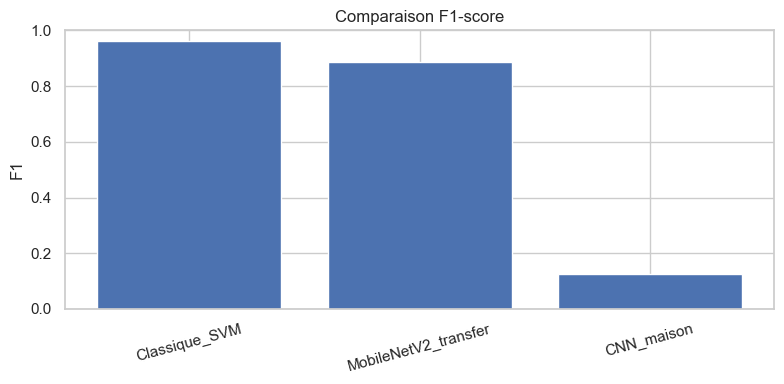

In [21]:
results = pd.DataFrame([
    {'modele': 'Classique_SVM', 'accuracy': acc_classic, 'precision': pr_classic, 'recall': rc_classic, 'f1': f1_classic, 'train_time_s': time_classic},
    {'modele': 'CNN_maison', 'accuracy': acc_cnn, 'precision': pr_cnn, 'recall': rc_cnn, 'f1': f1_cnn, 'train_time_s': time_cnn},
    {'modele': 'MobileNetV2_transfer', 'accuracy': acc_tl, 'precision': pr_tl, 'recall': rc_tl, 'f1': f1_tl, 'train_time_s': time_tl},
]).sort_values('f1', ascending=False)

display(results)

fig_dir = PROJECT_ROOT / "Rapports" / "Capture_ecran_Projet"
fig_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 4))
plt.bar(results['modele'], results['f1'])
plt.title('Comparaison F1-score')
plt.ylabel('F1')
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(fig_dir / "f1_comparison.png")
plt.show()

Image exemple: C:\Users\madaggag\Documents\Python\Project\Cours\Traitement_Image\im\panneaux\im01.png


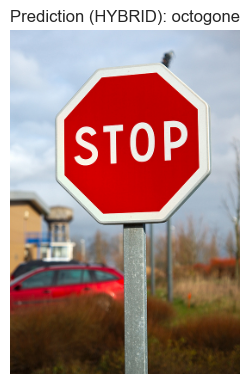

Modele utilise : hybrid
Classe predite : octogone
Top-3 classes :
  - 00004: 2.7337
  - 00030: 1.8548
  - 00016: 0.8878
Regle forme/couleur: {'pred_label': 'octogone', 'confidence': 0.88}


In [22]:
def _choose_model_for_inference(model_choice='auto'):
    choice = model_choice.lower()
    if choice == 'auto':
        # Sur ce mini dataset local, le mode hybride est plus robuste
        return 'hybrid'

    if choice not in {'svm', 'cnn', 'tl', 'hybrid', 'rule'}:
        raise ValueError("model_choice doit etre 'auto', 'svm', 'cnn', 'tl', 'hybrid' ou 'rule'.")
    return choice

def _predict_rule_only(img_bgr):
    if 'shape_pseudo_label' not in globals():
        raise RuntimeError("shape_pseudo_label n'est pas disponible.")
    lbl, conf = shape_pseudo_label(img_bgr)
    return {'pred_label': lbl, 'confidence': float(conf)}

def _predict_svm(img_path):
    if 'extract_features_classic' not in globals():
        raise RuntimeError('Fonction extract_features_classic absente. Relance la partie classique.')
    feat = extract_features_classic(str(img_path), size=IMG_SIZE).reshape(1, -1)
    feat_s = scaler.transform(feat)
    pred_idx = int(svm.predict(feat_s)[0])
    pred_label = class_names[pred_idx]

    top3 = [(pred_label, 1.0)]
    if hasattr(svm, 'decision_function'):
        scores = svm.decision_function(feat_s)
        classes_local = list(getattr(svm, 'classes_', []))

        if isinstance(scores, np.ndarray) and scores.ndim == 2:
            s = scores[0]
            order = np.argsort(s)[::-1][: min(3, len(s))]
            top3 = [(class_names[int(classes_local[i])], float(s[i])) for i in order]
        elif isinstance(scores, np.ndarray) and scores.ndim == 1:
            margin = float(scores[0])
            if len(classes_local) == 2:
                c0, c1 = int(classes_local[0]), int(classes_local[1])
                top3 = [
                    (class_names[c1], margin),
                    (class_names[c0], -margin),
                ] if margin >= 0 else [
                    (class_names[c0], -margin),
                    (class_names[c1], margin),
                ]
    return {'pred_label': pred_label, 'top3': top3}

def _predict_nn(img_bgr, model_kind='cnn'):
    target_size = IMG_TL if model_kind == 'tl' else IMG_SIZE
    model = tl_model if model_kind == 'tl' else cnn

    img_resized = cv2.resize(img_bgr, target_size, interpolation=cv2.INTER_AREA)
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    batch = np.expand_dims(img_rgb, axis=0)
    probs = model.predict(batch, verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    top_idx = np.argsort(probs)[::-1][: min(3, len(probs))]
    top3 = [(class_names[int(i)], float(probs[int(i)])) for i in top_idx]
    return {'pred_label': class_names[pred_idx], 'top3': top3}

def predict_sign_from_path(image_path, model_choice='auto', show_image=True):
    img_path = Path(image_path)
    if not img_path.exists():
        raise FileNotFoundError(f'Image introuvable: {img_path}')

    chosen = _choose_model_for_inference(model_choice)
    img_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise RuntimeError('Lecture image impossible (format non supporte ou fichier corrompu).')

    if chosen == 'rule':
        rule = _predict_rule_only(img_bgr)
        pred_label = rule['pred_label']
        top3 = [(pred_label, rule['confidence'])]
        model_used = 'rule'
    elif chosen == 'svm':
        out = _predict_svm(img_path)
        pred_label, top3 = out['pred_label'], out['top3']
        model_used = 'svm'
    elif chosen in {'cnn', 'tl'}:
        out = _predict_nn(img_bgr, model_kind=chosen)
        pred_label, top3 = out['pred_label'], out['top3']
        model_used = chosen
    else:
        # hybrid = regles + modele appris
        rule = _predict_rule_only(img_bgr)
        out_model = _predict_svm(img_path) if ('svm' in globals() and 'scaler' in globals()) else _predict_nn(img_bgr, model_kind='cnn')
        pred_model = out_model['pred_label']

        # Priorite aux regles si elles detectent clairement une forme de panneau
        if rule['pred_label'] != 'autre' and rule['confidence'] >= 0.75:
            pred_label = rule['pred_label']
        else:
            pred_label = pred_model

        top3 = out_model['top3']
        model_used = 'hybrid'

    if show_image:
        show_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(4, 4))
        plt.imshow(show_img)
        plt.title(f"Prediction ({model_used.upper()}): {pred_label}")
        plt.axis('off')
        plt.tight_layout()
        plt.show()

    print('Modele utilise :', model_used)
    print('Classe predite :', pred_label)
    print('Top-3 classes :')
    for name, score in top3:
        print(f'  - {name}: {score:.4f}')

    if chosen == 'hybrid':
        print('Regle forme/couleur:', _predict_rule_only(img_bgr))

    return {'model': model_used, 'pred_label': pred_label, 'top3': top3}

# Exemple d'utilisation
SAMPLE_SIGN_PATH = str((PROJECT_ROOT / 'im' / 'panneaux' / 'im01.png'))
print('Image exemple:', SAMPLE_SIGN_PATH)
_ = predict_sign_from_path(SAMPLE_SIGN_PATH, model_choice='auto', show_image=True)

## Inference - Donner une image, obtenir le panneau

Objectif: si tu fournis une image de panneau, le notebook renvoie la classe predite.

Utilisation simple:
- mets le chemin dans `SAMPLE_SIGN_PATH`
- execute la cellule de prediction

## Conclusion

- Le SVM avec descripteurs manuels donne une baseline rapide.
- Le CNN maison apprend des caractéristiques plus robustes.
- Le transfer learning est généralement le meilleur compromis performance/temps (selon données disponibles).

Limites : taille/qualité du dataset local, pseudo-labels si GTSRB absent.
Améliorations : plus de données annotées, augmentation avancée, réglage d'hyperparamètres.

In [23]:
print('=== Resume final ===')
best = results.iloc[0]
print('Meilleur modele :', best['modele'])
print(f"Meilleure accuracy : {best['accuracy']:.4f}")
print(f"Meilleure precision : {best['precision']:.4f}")
print(f"Meilleur recall : {best['recall']:.4f}")
print(f"Meilleur F1-score : {best['f1']:.4f}")
print(f"Temps entrainement : {best['train_time_s']:.2f}s")

=== Resume final ===
Meilleur modele : Classique_SVM
Meilleure accuracy : 0.9608
Meilleure precision : 0.9609
Meilleur recall : 0.9608
Meilleur F1-score : 0.9608
Temps entrainement : 11852.17s
